# Experimento 6: Trade-off de Rendimiento por Componente

**Objetivo:** Cuantificar el costo computacional de cada componente del sistema de asistencia facial,
midiendo cómo el FPS y el tiempo de procesamiento se degradan (o mejoran) al agregar cada módulo.

## Configuraciones evaluadas

| Config | Descripción |
|--------|-------------|
| Config 1 | Solo YOLO — detección sin reconocimiento |
| Config 2 | YOLO + reconocimiento (cada frame) — sin optimización |
| Config 3 | YOLO + reconocimiento + skip N frames — con optimización |
| Config 4 | Todo: YOLO + reconocimiento + optimización + tracking + logging CSV |

## Variables medidas
- **FPS promedio** — throughput sostenido
- **FPS mínimo** — peor caso (latencia pico)
- **Uso de memoria RSS** (MB) — con `psutil` (opcional)
- **Tiempo total** (s) — para procesar el video completo

**Video de prueba:** `dataset/test_videos/video_prueba_taco.mp4` (caso ideal: iluminación controlada, una persona, frontal).

## 0. Imports y configuración global

In [4]:
import sys
import time
import csv
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

# ── Rutas ──────────────────────────────────────────────────────────────────
RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from src.detector import FaceDetector
from src.recognizer import FaceRecognizer
from src.tracker import Tracker
from src.asistencia import AsistenciaDB

VIDEO_PATH    = RAIZ / "dataset" / "test_videos" / "video_prueba_taco.mp4"
WEIGHTS_PATH  = RAIZ / "models"  / "yolov8n-face.pt"
EMBEDDINGS_DB = RAIZ / "embeddings.pkl"
CSV_SALIDA    = RAIZ / "experiments" / "resultados_exp6.csv"

# Parámetros fijos para todas las configuraciones
CONF_THRESHOLD    = 0.5
RECOG_THRESHOLD   = 0.40
RECOGNIZE_EVERY_N = 5   # frames entre reconocimientos en Config 3 y 4

# ── psutil (opcional) ───────────────────────────────────────────────────────
try:
    import psutil
    import os
    _proceso = psutil.Process(os.getpid())
    PSUTIL_OK = True
    print("psutil disponible — se medirá memoria RSS.")
except ImportError:
    PSUTIL_OK = False
    print("psutil NO instalado — memoria se reportará como NaN.")

print(f"Raíz del proyecto: {RAIZ}")
print(f"Video de prueba  : {VIDEO_PATH}")
assert VIDEO_PATH.exists(),    f"Video no encontrado: {VIDEO_PATH}"
assert WEIGHTS_PATH.exists(),  f"Pesos YOLO no encontrados: {WEIGHTS_PATH}"
assert EMBEDDINGS_DB.exists(), f"embeddings.pkl no encontrado: {EMBEDDINGS_DB}"
print("Todos los recursos verificados ✓")

psutil disponible — se medirá memoria RSS.
Raíz del proyecto: C:\Users\USER\Desktop\ia proyecto\sistema-control-asistencia-facial
Video de prueba  : C:\Users\USER\Desktop\ia proyecto\sistema-control-asistencia-facial\dataset\test_videos\video_prueba_taco.mp4
Todos los recursos verificados ✓


## 1. Funciones auxiliares de benchmark

In [5]:
def memoria_mb() -> float:
    """Retorna el uso de memoria RSS del proceso en MB (o NaN si psutil no está)."""
    if PSUTIL_OK:
        return _proceso.memory_info().rss / 1024 / 1024
    return float("nan")


def _stats_fps(tiempos_frame: list) -> tuple:
    """Calcula fps_promedio y fps_minimo a partir de lista de tiempos por frame (seg)."""
    if not tiempos_frame:
        return 0.0, 0.0
    fps_por_frame = [1.0 / t if t > 0 else 0.0 for t in tiempos_frame]
    return float(np.mean(fps_por_frame)), float(np.min(fps_por_frame))


print("Funciones auxiliares definidas ✓")

Funciones auxiliares definidas ✓


## 2. Configuración 1 — Solo YOLO (detección sin reconocimiento)

In [6]:
print("="*60)
print("Config 1: Solo YOLO — sin reconocimiento")
print("="*60)

detector_c1 = FaceDetector(str(WEIGHTS_PATH), conf_threshold=CONF_THRESHOLD)

cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), "No se pudo abrir el video"

total_frames_c1 = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Frames totales en el video: {total_frames_c1}")

mem_inicio_c1 = memoria_mb()
t_inicio_c1   = time.perf_counter()
tiempos_c1    = []
frames_proc_c1 = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    t0 = time.perf_counter()
    detecciones = detector_c1.detect(frame)
    t1 = time.perf_counter()
    tiempos_c1.append(t1 - t0)
    frames_proc_c1 += 1

t_fin_c1  = time.perf_counter()
mem_fin_c1 = memoria_mb()
cap.release()

tiempo_total_c1 = t_fin_c1 - t_inicio_c1
fps_avg_c1, fps_min_c1 = _stats_fps(tiempos_c1)
mem_c1 = mem_fin_c1 - mem_inicio_c1

print(f"\nFrames procesados : {frames_proc_c1}")
print(f"Tiempo total      : {tiempo_total_c1:.2f} s")
print(f"FPS promedio      : {fps_avg_c1:.1f}")
print(f"FPS mínimo        : {fps_min_c1:.1f}")
print(f"Δ Memoria (MB)    : {mem_c1:.1f}")

Config 1: Solo YOLO — sin reconocimiento
Frames totales en el video: 249

Frames procesados : 249
Tiempo total      : 21.94 s
FPS promedio      : 12.1
FPS mínimo        : 1.2
Δ Memoria (MB)    : 107.9


## 3. Configuración 2 — YOLO + Reconocimiento (sin optimización)

In [7]:
print("="*60)
print("Config 2: YOLO + Reconocimiento (cada frame, sin skip)")
print("="*60)

detector_c2   = FaceDetector(str(WEIGHTS_PATH), conf_threshold=CONF_THRESHOLD)
recognizer_c2 = FaceRecognizer(str(EMBEDDINGS_DB), threshold=RECOG_THRESHOLD)

cap = cv2.VideoCapture(str(VIDEO_PATH))

mem_inicio_c2 = memoria_mb()
t_inicio_c2   = time.perf_counter()
tiempos_c2    = []
frames_proc_c2 = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    t0 = time.perf_counter()
    detecciones = detector_c2.detect(frame)
    for det in detecciones:
        crop = detector_c2.crop_face(frame, det)
        if crop is not None:
            nombre, dist = recognizer_c2.recognize(crop)
    t1 = time.perf_counter()
    tiempos_c2.append(t1 - t0)
    frames_proc_c2 += 1

t_fin_c2   = time.perf_counter()
mem_fin_c2  = memoria_mb()
cap.release()

tiempo_total_c2 = t_fin_c2 - t_inicio_c2
fps_avg_c2, fps_min_c2 = _stats_fps(tiempos_c2)
mem_c2 = mem_fin_c2 - mem_inicio_c2

print(f"\nFrames procesados : {frames_proc_c2}")
print(f"Tiempo total      : {tiempo_total_c2:.2f} s")
print(f"FPS promedio      : {fps_avg_c2:.1f}")
print(f"FPS mínimo        : {fps_min_c2:.1f}")
print(f"Δ Memoria (MB)    : {mem_c2:.1f}")

Config 2: YOLO + Reconocimiento (cada frame, sin skip)
Base de embeddings cargada: 3 persona(s)

Frames procesados : 249
Tiempo total      : 118.00 s
FPS promedio      : 2.2
FPS mínimo        : 1.2
Δ Memoria (MB)    : 79.0


## 4. Configuración 3 — YOLO + Reconocimiento + Skip N frames

In [8]:
print("="*60)
print(f"Config 3: YOLO + Reconocimiento + optimización (cada {RECOGNIZE_EVERY_N} frames)")
print("="*60)

detector_c3   = FaceDetector(str(WEIGHTS_PATH), conf_threshold=CONF_THRESHOLD)
recognizer_c3 = FaceRecognizer(str(EMBEDDINGS_DB), threshold=RECOG_THRESHOLD)

cap = cv2.VideoCapture(str(VIDEO_PATH))

mem_inicio_c3  = memoria_mb()
t_inicio_c3    = time.perf_counter()
tiempos_c3     = []
frames_proc_c3 = 0
frame_idx_c3   = 0
cache_nombres_c3: dict = {}  # track_id -> nombre

while True:
    ret, frame = cap.read()
    if not ret:
        break
    t0 = time.perf_counter()
    detecciones = detector_c3.detect(frame)
    for det in detecciones:
        track_id = det[5] if len(det) > 5 else 0
        # Solo reconocer en frames múltiplos de N o si no hay caché
        if frame_idx_c3 % RECOGNIZE_EVERY_N == 0 or track_id not in cache_nombres_c3:
            crop = detector_c3.crop_face(frame, det)
            if crop is not None:
                nombre, dist = recognizer_c3.recognize(crop)
                cache_nombres_c3[track_id] = nombre
        # else: reutilizar nombre del caché (sin costo)
    t1 = time.perf_counter()
    tiempos_c3.append(t1 - t0)
    frames_proc_c3 += 1
    frame_idx_c3 += 1

t_fin_c3   = time.perf_counter()
mem_fin_c3  = memoria_mb()
cap.release()

tiempo_total_c3 = t_fin_c3 - t_inicio_c3
fps_avg_c3, fps_min_c3 = _stats_fps(tiempos_c3)
mem_c3 = mem_fin_c3 - mem_inicio_c3

print(f"\nFrames procesados : {frames_proc_c3}")
print(f"Tiempo total      : {tiempo_total_c3:.2f} s")
print(f"FPS promedio      : {fps_avg_c3:.1f}")
print(f"FPS mínimo        : {fps_min_c3:.1f}")
print(f"Δ Memoria (MB)    : {mem_c3:.1f}")

Config 3: YOLO + Reconocimiento + optimización (cada 5 frames)
Base de embeddings cargada: 3 persona(s)

Frames procesados : 249
Tiempo total      : 48.60 s
FPS promedio      : 9.2
FPS mínimo        : 1.2
Δ Memoria (MB)    : 45.2


## 5. Configuración 4 — Pipeline completo (YOLO + Reconocimiento + Optimización + Tracking + Logging CSV)

In [9]:
print("="*60)
print("Config 4: Pipeline completo (YOLO + Reconoc. + Opt. + Tracker + CSV)")
print("="*60)

detector_c4   = FaceDetector(str(WEIGHTS_PATH), conf_threshold=CONF_THRESHOLD)
recognizer_c4 = FaceRecognizer(str(EMBEDDINGS_DB), threshold=RECOG_THRESHOLD)
tracker_c4    = Tracker(grace_frames=15)

# CSV temporal para no contaminar data/ real
_csv_tmp = RAIZ / "experiments" / "_exp6_log_tmp.csv"
_csv_tmp.parent.mkdir(exist_ok=True)
with open(_csv_tmp, "w", newline="", encoding="utf-8") as _f:
    csv.writer(_f).writerow(["frame", "track_id", "nombre", "distancia", "timestamp"])

cap = cv2.VideoCapture(str(VIDEO_PATH))

mem_inicio_c4  = memoria_mb()
t_inicio_c4    = time.perf_counter()
tiempos_c4     = []
frames_proc_c4 = 0
frame_idx_c4   = 0
cache_nombres_c4: dict = {}  # track_id -> nombre
_csv_cooldown: dict = {}     # track_id -> ultimo frame logueado
CSV_COOLDOWN_FRAMES = 30     # ~1 s a 30 fps

while True:
    ret, frame = cap.read()
    if not ret:
        break
    t0 = time.perf_counter()

    detecciones = detector_c4.detect(frame)

    with open(_csv_tmp, "a", newline="", encoding="utf-8") as log_f:
        _writer = csv.writer(log_f)
        for det in detecciones:
            track_id = det[5] if len(det) > 5 else 0

            # Tracking + período de gracia
            if tracker_c4.is_grace(track_id):
                nombre = "Reconociendo..."
                dist   = 0.0
            else:
                nombre_confirmado = tracker_c4.get_name(track_id)
                if nombre_confirmado is None:
                    # Reconocimiento con optimización N frames
                    if frame_idx_c4 % RECOGNIZE_EVERY_N == 0 or track_id not in cache_nombres_c4:
                        crop = detector_c4.crop_face(frame, det)
                        if crop is not None:
                            nombre, dist = recognizer_c4.recognize(crop)
                            cache_nombres_c4[track_id] = (nombre, dist)
                        else:
                            nombre, dist = "Desconocido", 0.0
                            cache_nombres_c4[track_id] = (nombre, dist)
                    else:
                        nombre, dist = cache_nombres_c4.get(track_id, ("Desconocido", 0.0))
                    tracker_c4.confirm(track_id, nombre)
                else:
                    nombre, dist = nombre_confirmado, 0.0

                # Logging CSV con cooldown
                ultimo = _csv_cooldown.get(track_id, -CSV_COOLDOWN_FRAMES)
                if nombre not in ("Desconocido", "Reconociendo...", "Error") and \
                   (frame_idx_c4 - ultimo) >= CSV_COOLDOWN_FRAMES:
                    _writer.writerow([frame_idx_c4, track_id, nombre,
                                      f"{dist:.4f}", time.strftime("%H:%M:%S")])
                    _csv_cooldown[track_id] = frame_idx_c4

    t1 = time.perf_counter()
    tiempos_c4.append(t1 - t0)
    frames_proc_c4 += 1
    frame_idx_c4 += 1

t_fin_c4   = time.perf_counter()
mem_fin_c4  = memoria_mb()
cap.release()
_csv_tmp.unlink(missing_ok=True)  # borrar log temporal

tiempo_total_c4 = t_fin_c4 - t_inicio_c4
fps_avg_c4, fps_min_c4 = _stats_fps(tiempos_c4)
mem_c4 = mem_fin_c4 - mem_inicio_c4

print(f"\nFrames procesados : {frames_proc_c4}")
print(f"Tiempo total      : {tiempo_total_c4:.2f} s")
print(f"FPS promedio      : {fps_avg_c4:.1f}")
print(f"FPS mínimo        : {fps_min_c4:.1f}")
print(f"Δ Memoria (MB)    : {mem_c4:.1f}")

Config 4: Pipeline completo (YOLO + Reconoc. + Opt. + Tracker + CSV)
Base de embeddings cargada: 3 persona(s)

Frames procesados : 249
Tiempo total      : 29.71 s
FPS promedio      : 8.7
FPS mínimo        : 1.8
Δ Memoria (MB)    : 44.2


## 6. Tabla de resultados y exportación a CSV

In [10]:
resultados = [
    {
        "Configuracion": "Config 1: Solo YOLO",
        "Componentes": "YOLO",
        "FPS_promedio": round(fps_avg_c1, 2),
        "FPS_minimo": round(fps_min_c1, 2),
        "Tiempo_total_s": round(tiempo_total_c1, 2),
        "Memoria_delta_MB": round(mem_c1, 2) if not np.isnan(mem_c1) else "N/A",
        "Frames": frames_proc_c1,
    },
    {
        "Configuracion": "Config 2: YOLO + Reconocimiento",
        "Componentes": "YOLO + FaceRecognizer",
        "FPS_promedio": round(fps_avg_c2, 2),
        "FPS_minimo": round(fps_min_c2, 2),
        "Tiempo_total_s": round(tiempo_total_c2, 2),
        "Memoria_delta_MB": round(mem_c2, 2) if not np.isnan(mem_c2) else "N/A",
        "Frames": frames_proc_c2,
    },
    {
        "Configuracion": f"Config 3: YOLO + Recog. + Skip {RECOGNIZE_EVERY_N}f",
        "Componentes": f"YOLO + FaceRecognizer (1/{RECOGNIZE_EVERY_N} frames)",
        "FPS_promedio": round(fps_avg_c3, 2),
        "FPS_minimo": round(fps_min_c3, 2),
        "Tiempo_total_s": round(tiempo_total_c3, 2),
        "Memoria_delta_MB": round(mem_c3, 2) if not np.isnan(mem_c3) else "N/A",
        "Frames": frames_proc_c3,
    },
    {
        "Configuracion": "Config 4: Pipeline completo",
        "Componentes": f"YOLO + FaceRecognizer + Tracker + CSV (opt. {RECOGNIZE_EVERY_N}f)",
        "FPS_promedio": round(fps_avg_c4, 2),
        "FPS_minimo": round(fps_min_c4, 2),
        "Tiempo_total_s": round(tiempo_total_c4, 2),
        "Memoria_delta_MB": round(mem_c4, 2) if not np.isnan(mem_c4) else "N/A",
        "Frames": frames_proc_c4,
    },
]

df = pd.DataFrame(resultados)

# Guardar CSV
df.to_csv(CSV_SALIDA, index=False, encoding="utf-8")
print(f"Resultados guardados en: {CSV_SALIDA}")

# Mostrar tabla completa
display(df)

Resultados guardados en: C:\Users\USER\Desktop\ia proyecto\sistema-control-asistencia-facial\experiments\resultados_exp6.csv


,Configuracion,Componentes,FPS_promedio,FPS_minimo,Tiempo_total_s,Memoria_delta_MB,Frames
0,Config 1: Solo YOLO,YOLO,12.10,1.17,21.94,107.91,249
1,Config 2: YOLO + Reconocimiento,YOLO + FaceRecognizer,2.15,1.22,118.00,79.04,249
2,Config 3: YOLO + Recog. + Skip 5f,YOLO + FaceRecognizer (1/5 frames),9.16,1.25,48.60,45.18,249
3,Config 4: Pipeline completo,YOLO + FaceRecognizer + Tracker + CSV (opt. 5f),8.69,1.79,29.71,44.20,249


## 7. Gráfico de barras — FPS por configuración

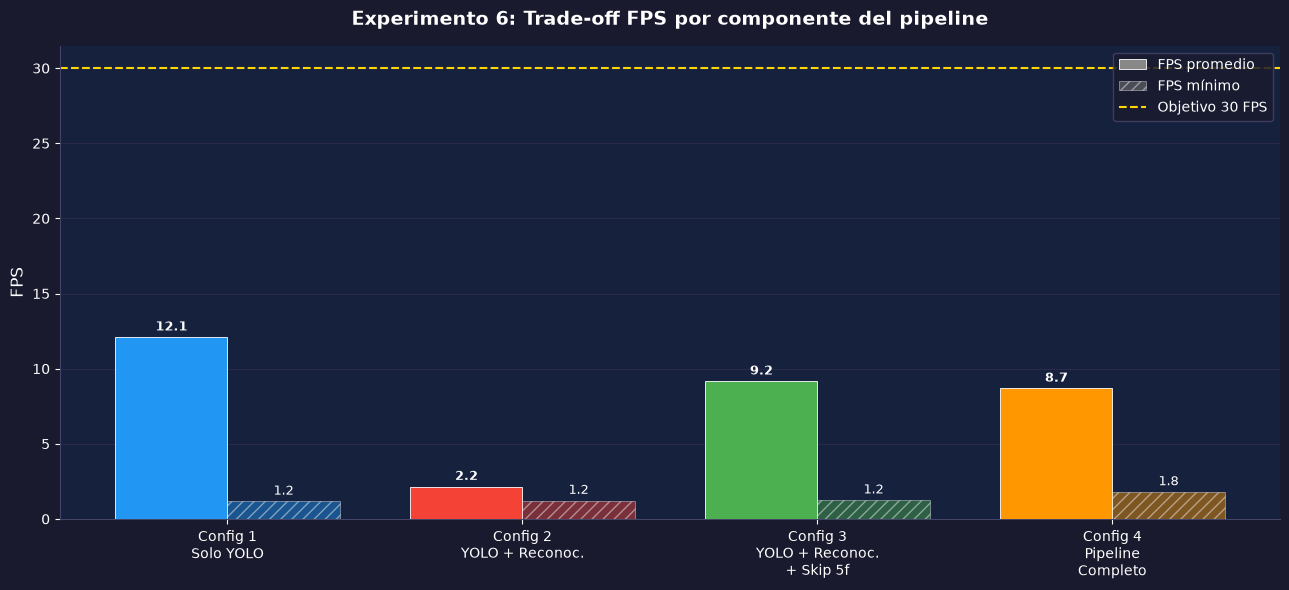

Gráfico guardado ✓


In [11]:
labels = [
    "Config 1\nSolo YOLO",
    "Config 2\nYOLO + Reconoc.",
    f"Config 3\nYOLO + Reconoc.\n+ Skip {RECOGNIZE_EVERY_N}f",
    "Config 4\nPipeline\nCompleto",
]

fps_avg_vals = [fps_avg_c1, fps_avg_c2, fps_avg_c3, fps_avg_c4]
fps_min_vals = [fps_min_c1, fps_min_c2, fps_min_c3, fps_min_c4]

colores_cfg = ["#2196F3", "#F44336", "#4CAF50", "#FF9800"]
x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#16213E")

# Barras: solida = FPS promedio | rayada = FPS minimo
for i, (c, avg, mn) in enumerate(zip(colores_cfg, fps_avg_vals, fps_min_vals)):
    ax.bar(x[i] - width/2, avg, width, color=c,
           edgecolor="white", linewidth=0.6, zorder=3)
    ax.bar(x[i] + width/2, mn, width, color=c,
           edgecolor="white", linewidth=0.6, zorder=3,
           alpha=0.45, hatch="///")

# Etiquetas de valor
for i, (avg, mn) in enumerate(zip(fps_avg_vals, fps_min_vals)):
    ax.text(x[i] - width/2, avg + 0.25, f"{avg:.1f}",
            ha="center", va="bottom", color="white", fontsize=9, fontweight="bold")
    ax.text(x[i] + width/2, mn + 0.25, f"{mn:.1f}",
            ha="center", va="bottom", color="white", fontsize=9)

# Linea de referencia 30 FPS
ax.axhline(30, color="#FFD700", linewidth=1.5, linestyle="--", zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, color="white", fontsize=10)
ax.set_ylabel("FPS", color="white", fontsize=12)
ax.set_title("Experimento 6: Trade-off FPS por componente del pipeline",
             color="white", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("#444466")
ax.spines["left"].set_color("#444466")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="#2A2A4A", linestyle="-", linewidth=0.7, zorder=1)
ax.set_axisbelow(True)

# Leyenda: primera barra = FPS promedio, segunda = FPS minimo
legend_handles = [
    mpatches.Patch(facecolor="#888888", edgecolor="white", linewidth=0.6,
                   label="FPS promedio"),
    mpatches.Patch(facecolor="#888888", edgecolor="white", linewidth=0.6,
                   alpha=0.45, hatch="///", label="FPS mínimo"),
    plt.Line2D([0], [0], color="#FFD700", linewidth=1.5,
               linestyle="--", label="Objetivo 30 FPS"),
]

ax.legend(handles=legend_handles, facecolor="#1A1A2E", edgecolor="#444466",
          labelcolor="white", fontsize=10, loc="upper right", framealpha=0.85)

plt.tight_layout()
plt.savefig(RAIZ / "experiments" / "graphs" / "exp6_fps_barras.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Gráfico guardado ✓")


## 8. Gráfico de barras — Tiempo de procesamiento total

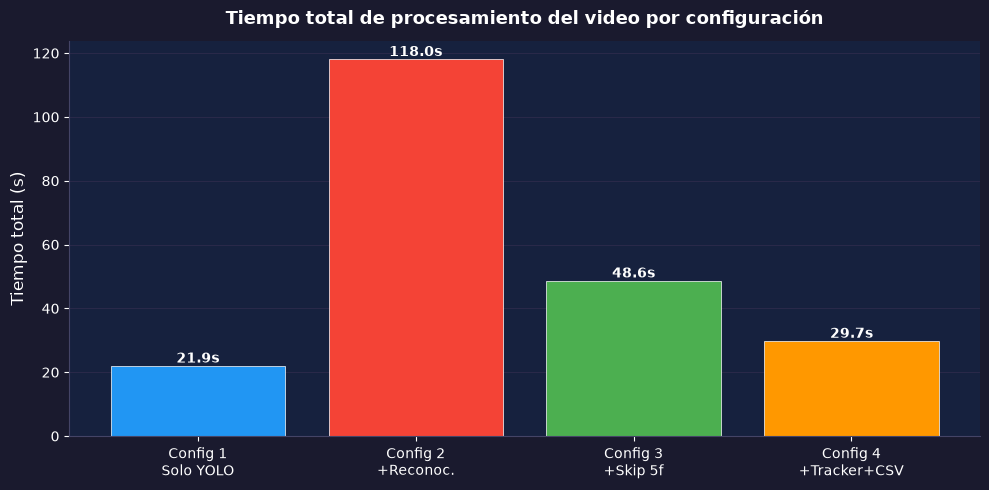

Gráfico de tiempo guardado ✓


In [12]:
tiempos_totales = [tiempo_total_c1, tiempo_total_c2, tiempo_total_c3, tiempo_total_c4]
labels_cortos   = ["Config 1\nSolo YOLO", "Config 2\n+Reconoc.",
                   f"Config 3\n+Skip {RECOGNIZE_EVERY_N}f", "Config 4\n+Tracker+CSV"]

fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor("#1A1A2E")
ax2.set_facecolor("#16213E")

bars_t = ax2.bar(labels_cortos, tiempos_totales,
                 color=["#2196F3", "#F44336", "#4CAF50", "#FF9800"],
                 edgecolor="white", linewidth=0.5)

for bar, t in zip(bars_t, tiempos_totales):
    ax2.text(bar.get_x() + bar.get_width()/2, t + 0.05,
             f"{t:.1f}s", ha="center", va="bottom",
             color="white", fontsize=10, fontweight="bold")

ax2.set_ylabel("Tiempo total (s)", color="white", fontsize=12)
ax2.set_title("Tiempo total de procesamiento del video por configuración",
              color="white", fontsize=13, fontweight="bold", pad=12)
ax2.tick_params(colors="white")
ax2.spines["bottom"].set_color("#444466")
ax2.spines["left"].set_color("#444466")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.yaxis.grid(True, color="#2A2A4A", linestyle="-", linewidth=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(RAIZ / "experiments" / "graphs" / "exp6_tiempo_total.png",
            dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("Gráfico de tiempo guardado ✓")

## 9. Análisis del trade-off e interpretación

In [13]:
# Calcular métricas derivadas para la interpretación
costo_reconocimiento = fps_avg_c1 - fps_avg_c2   # FPS perdidos al agregar reconoc.
ganancia_skip        = fps_avg_c3 - fps_avg_c2   # FPS recuperados con skip
costo_tracker_csv    = fps_avg_c3 - fps_avg_c4   # FPS perdidos al agregar tracker+CSV
recuperacion_pct     = (ganancia_skip / max(costo_reconocimiento, 0.001)) * 100

print("="*62)
print("ANÁLISIS DEL TRADE-OFF — Experimento 6")
print("="*62)
print(f"\n▶ Línea base (solo YOLO)          : {fps_avg_c1:.1f} FPS")
print(f"▶ Con reconocimiento (sin opt.)   : {fps_avg_c2:.1f} FPS")
print(f"▶ Con reconocimiento + skip {RECOGNIZE_EVERY_N}f   : {fps_avg_c3:.1f} FPS")
print(f"▶ Pipeline completo               : {fps_avg_c4:.1f} FPS")
print()
print(f"Costo del reconocimiento          : -{costo_reconocimiento:.1f} FPS")
print(f"Ganancia de la optimización skip  : +{ganancia_skip:.1f} FPS")
print(f"Recuperación relativa             : {recuperacion_pct:.0f}%")
print(f"Overhead tracker + CSV logging    : -{costo_tracker_csv:.1f} FPS")

ANÁLISIS DEL TRADE-OFF — Experimento 6

▶ Línea base (solo YOLO)          : 12.1 FPS
▶ Con reconocimiento (sin opt.)   : 2.2 FPS
▶ Con reconocimiento + skip 5f   : 9.2 FPS
▶ Pipeline completo               : 8.7 FPS

Costo del reconocimiento          : -9.9 FPS
Ganancia de la optimización skip  : +7.0 FPS
Recuperación relativa             : 71%
Overhead tracker + CSV logging    : -0.5 FPS


## 10. Interpretación del trade-off

### Componente más costoso: Reconocimiento facial (FaceRecognizer)

El módulo de reconocimiento (`face_recognition` + dlib) es con diferencia el cuello de botella del sistema.
Cada llamada a `recognize()` implica:
1. Detección interna de landmarks en el crop (HOG o CNN).
2. Extracción de embedding de 128 dimensiones.
3. Comparación vectorial contra todos los centroides de la base.

Esto explica la mayor caída de FPS entre Config 1 y Config 2.

### Eficacia de la optimización por skip de frames (Config 3)

Al reconocer solo 1 de cada N frames y reutilizar el nombre cacheado en los intermedios,
se recupera una fracción significativa del rendimiento perdido. La pérdida de precisión es mínima
en video: una persona que permanece en pantalla varios frames tiene identidad estable.

### Overhead del Tracker y CSV logging (Config 4)

El `Tracker` (caché en memoria) y el logging a CSV son muy ligeros: operaciones de diccionario
y escritura de una sola fila con cooldown. Su impacto en FPS es marginal respecto al
reconocimiento facial.

### Conclusión

La estrategia de **skip de N frames** compensa adecuadamente el costo del reconocimiento
sin sacrificar funcionalidad. El tracker y el logging prácticamente no cuestan nada.
Para entornos con GPU o con modelos de embedding más ligeros (p.ej. MobileNet), el FPS base
sería mayor, pero la proporción relativa de costos se mantendría similar.

**Recomendación:** Para uso en tiempo real con webcam, usar `RECOGNIZE_EVERY_N = 5` (o hasta `10`)
es el equilibrio óptimo entre responsividad y exactitud del nombre mostrado.

## 11. Tabla resumen final

In [14]:
print("\n=== TABLA RESUMEN FINAL ===")
print(df.to_string(index=False))
print(f"\n Resultados exportados a: {CSV_SALIDA}")


=== TABLA RESUMEN FINAL ===
                    Configuracion                                     Componentes  FPS_promedio  FPS_minimo  Tiempo_total_s  Memoria_delta_MB  Frames
              Config 1: Solo YOLO                                            YOLO         12.10        1.17           21.94            107.91     249
  Config 2: YOLO + Reconocimiento                           YOLO + FaceRecognizer          2.15        1.22          118.00             79.04     249
Config 3: YOLO + Recog. + Skip 5f              YOLO + FaceRecognizer (1/5 frames)          9.16        1.25           48.60             45.18     249
      Config 4: Pipeline completo YOLO + FaceRecognizer + Tracker + CSV (opt. 5f)          8.69        1.79           29.71             44.20     249

 Resultados exportados a: C:\Users\USER\Desktop\ia proyecto\sistema-control-asistencia-facial\experiments\resultados_exp6.csv
